In [2]:
#╔══════════════════════════════════════════════════════════════╗
# ║  02_cleaning_qa.ipynb — DriftFire                          ║
# ║  Data Quality Assurance & Validation                       ║
# ║  Copy each CELL block into a separate Jupyter cell.        ║
# ║  7 cells total.                                            ║
# ╚══════════════════════════════════════════════════════════════╝
 
 
# ============================================================
# CELL 1 — Imports & Load Data
# ============================================================
# WHAT THIS DOES:
#   Loads clean.parquet from notebook 01 and verifies the
#   schema matches what we expect (24 columns, 844K+ rows).
#
# WHAT YOU SHOULD SEE:
#   Shape, column list, date range, ticker count — all matching
#   the Cell 5 output from the previous notebook.
# ============================================================
 
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
 
PROJECT_ROOT = Path.cwd().parent
PROC_DIR     = PROJECT_ROOT / "data" / "processed"
FIG_DIR      = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
 
# --- load ---
df = pd.read_parquet(PROC_DIR / "clean.parquet")
 
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique tickers: {df['ticker'].nunique()}")
print(f"ETFs: {df[df['is_etf']]['ticker'].nunique()}  |  "
      f"Stocks: {df[~df['is_etf']]['ticker'].nunique()}")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()
 
 

Matplotlib is building the font cache; this may take a moment.


Shape: 844,614 rows × 24 cols
Date range: 2018-01-02 → 2024-12-30
Unique tickers: 484
ETFs: 12  |  Stocks: 472

Columns:
['date', 'open', 'high', 'low', 'close', 'volume', 'ticker', 'is_etf', 'ema8', 'ema21', 'ema50', 'avg_vol_10d', 'avg_vol_20d', 'daily_chg_pct', 'dollar_volume', 'prev_close', 'prev_ema8', 'prev_ema21', 'prev_ema50', 'prev_avg_vol_10d', 'prev_avg_vol_20d', 'prev_daily_chg_pct', 'prev_dollar_volume', 'screener_pass']

First 5 rows:


,date,open,high,low,close,volume,ticker,is_etf,ema8,ema21,...,dollar_volume,prev_close,prev_ema8,prev_ema21,prev_ema50,prev_avg_vol_10d,prev_avg_vol_20d,prev_daily_chg_pct,prev_dollar_volume,screener_pass
0,2018-01-02,63.353622,63.795276,63.278446,63.522766,1047800.0,A,False,63.522766,63.522766,...,6.655915e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2018-01-03,63.541567,65.298775,63.522769,65.139030,1698900.0,A,False,63.881936,63.669699,...,1.106647e+08,63.522766,63.522766,63.522766,63.522766,NaN,NaN,NaN,6.655915e+07,False
2,2018-01-04,65.345748,65.608859,64.631585,64.650383,2230700.0,A,False,64.052702,63.758852,...,1.442156e+08,65.139030,63.881936,63.669699,63.586149,NaN,NaN,2.544386,1.106647e+08,False
3,2018-01-05,64.584606,65.871971,64.584606,65.684036,1632500.0,A,False,64.415221,63.933869,...,1.072292e+08,64.650383,64.052702,63.758852,63.627884,NaN,NaN,-0.750161,1.442156e+08,False
4,2018-01-08,65.524305,66.088116,65.355162,65.825005,1613400.0,A,False,64.728506,64.105790,...,1.062021e+08,65.684036,64.415221,63.933869,63.708517,NaN,NaN,1.598835,1.072292e+08,False


In [5]:
# ============================================================
# CELL 2 — Missing Value Audit
# ============================================================
# WHAT THIS DOES:
#   Counts NaN values per column. Some NaNs are expected:
#     - ema50 needs 50 days of history to warm up
#     - avg_vol_10d / avg_vol_20d need 10/20 days
#     - prev_* columns lose their first row per ticker (shift)
#     - daily_chg_pct loses the first row per ticker (pct_change)
#   Unexpected NaNs in close, open, volume = data quality issue.
#
# WHAT YOU SHOULD SEE:
#   Zero NaNs in date, ticker, close, open, high, low, volume.
#   Non-zero NaNs in rolling/shifted columns (expected).
#   A per-ticker breakdown of how many rows have NaN ema50.
# ============================================================
 
# --- overall NaN count ---
nan_counts = df.isnull().sum()
nan_pct    = (df.isnull().sum() / len(df) * 100).round(2)
nan_report = pd.DataFrame({"nan_count": nan_counts, "nan_pct": nan_pct})
nan_report = nan_report[nan_report["nan_count"] > 0].sort_values("nan_count", ascending=False)
 
print("MISSING VALUES (columns with NaNs only)")
print("=" * 50)
if len(nan_report) == 0:
    print("No missing values found anywhere. ✓")
else:
    print(nan_report.to_string())
 
# --- critical columns must have ZERO NaNs ---
critical = ["date", "ticker", "open", "high", "low", "close", "volume"]
critical_nans = df[critical].isnull().sum()
critical_issues = critical_nans[critical_nans > 0]
 
if len(critical_issues) == 0:
    print(f"\n✅ All {len(critical)} critical columns have zero NaNs.")
else:
    print(f"\n❌ CRITICAL NaN ISSUES:")
    print(critical_issues)
 
# --- expected NaN warmup check ---
# Each ticker's first 49 rows won't have ema50 (needs 50 data points
# for ewm to stabilize, but ewm actually computes from row 1 —
# the NaNs come from rolling min_periods and shift instead)
stocks_only = df[~df["is_etf"]]
warmup_nans = stocks_only.groupby("ticker")["prev_ema50"].apply(
    lambda x: x.isnull().sum()
)
print(f"\nWarmup NaN check (prev_ema50 per ticker):")
print(f"  Min NaN rows per ticker : {warmup_nans.min()}")
print(f"  Max NaN rows per ticker : {warmup_nans.max()}")
print(f"  Median                  : {warmup_nans.median():.0f}")
print(f"  (Expected: ~50-60 rows per ticker from EMA warmup + shift)")
 

MISSING VALUES (columns with NaNs only)
                    nan_count  nan_pct
prev_avg_vol_20d         9680     1.15
avg_vol_20d              9196     1.09
prev_avg_vol_10d         4840     0.57
avg_vol_10d              4356     0.52
prev_daily_chg_pct        968     0.11
daily_chg_pct             484     0.06
prev_close                484     0.06
prev_ema8                 484     0.06
prev_ema21                484     0.06
prev_ema50                484     0.06
prev_dollar_volume        484     0.06

✅ All 7 critical columns have zero NaNs.

Warmup NaN check (prev_ema50 per ticker):
  Min NaN rows per ticker : 1
  Max NaN rows per ticker : 1
  Median                  : 1
  (Expected: ~50-60 rows per ticker from EMA warmup + shift)


In [6]:
# ============================================================
# CELL 3 — Duplicate & Integrity Checks
# ============================================================
# WHAT THIS DOES:
#   1. Checks for duplicate (ticker, date) pairs — there should
#      be zero. A duplicate means the reshape went wrong.
#   2. Checks that every ticker has continuous trading dates
#      (no random gaps beyond normal market holidays/weekends).
#   3. Validates row counts per ticker are reasonable.
#
# WHAT YOU SHOULD SEE:
#   "0 duplicate rows ✓" and a distribution of rows-per-ticker
#   clustered around 1,700-1,760 (some tickers IPO'd mid-period
#   so they'll have fewer rows, which is fine).
# ============================================================
 
# --- 1. Duplicate check ---
dupes = df.duplicated(subset=["ticker", "date"], keep=False).sum()
print(f"Duplicate (ticker, date) rows: {dupes}")
if dupes == 0:
    print("✅ No duplicates.")
else:
    print("❌ DUPLICATES FOUND — inspect with:")
    print("   df[df.duplicated(subset=['ticker','date'], keep=False)]")
 
# --- 2. Rows per ticker distribution ---
rows_per_ticker = df.groupby("ticker").size().rename("row_count")
print(f"\nRows per ticker:")
print(f"  Min   : {rows_per_ticker.min()} ({rows_per_ticker.idxmin()})")
print(f"  Max   : {rows_per_ticker.max()} ({rows_per_ticker.idxmax()})")
print(f"  Median: {rows_per_ticker.median():.0f}")
print(f"  Mean  : {rows_per_ticker.mean():.0f}")
 
# --- flag tickers with very few rows (< 252 = less than 1 year) ---
short_tickers = rows_per_ticker[rows_per_ticker < 252]
if len(short_tickers) > 0:
    print(f"\n⚠️  {len(short_tickers)} tickers have < 252 trading days (< 1 year):")
    print(f"   {short_tickers.index.tolist()}")
    print(f"   These likely IPO'd during the sample or were delisted.")
    print(f"   They're fine to keep — the screener naturally filters them")
    print(f"   out on days they don't exist.")
else:
    print(f"\n✅ All tickers have at least 1 year of data.")
 
# --- 3. Date continuity spot check ---
# Pick 5 random tickers and verify no unexpected gaps
sample_tickers = df[~df["is_etf"]]["ticker"].drop_duplicates().sample(5, random_state=42)
all_trading_dates = df["date"].drop_duplicates().sort_values()
 
print(f"\nDate continuity spot check (5 random tickers):")
for t in sample_tickers:
    ticker_dates = df[df["ticker"] == t]["date"].sort_values()
    first = ticker_dates.iloc[0].date()
    last  = ticker_dates.iloc[-1].date()
    # expected trading days between first and last
    expected = all_trading_dates[(all_trading_dates >= ticker_dates.iloc[0]) &
                                 (all_trading_dates <= ticker_dates.iloc[-1])]
    missing = len(expected) - len(ticker_dates)
    status = "✓" if missing <= 5 else f"⚠️ {missing} missing"
    print(f"  {t:6s} | {first} → {last} | {len(ticker_dates):,} days | {status}")
 

Duplicate (ticker, date) rows: 0
✅ No duplicates.

Rows per ticker:
  Min   : 93 (SBNY)
  Max   : 1760 (A)
  Median: 1760
  Mean  : 1745

⚠️  1 tickers have < 252 trading days (< 1 year):
   ['SBNY']
   These likely IPO'd during the sample or were delisted.
   They're fine to keep — the screener naturally filters them
   out on days they don't exist.

Date continuity spot check (5 random tickers):
  BF-B   | 2018-01-02 → 2024-12-30 | 1,760 days | ✓
  CARR   | 2020-03-19 → 2024-12-30 | 1,204 days | ✓
  AMZN   | 2018-01-02 → 2024-12-30 | 1,760 days | ✓
  MDT    | 2018-01-02 → 2024-12-30 | 1,760 days | ✓
  KLAC   | 2018-01-02 → 2024-12-30 | 1,760 days | ✓


In [7]:
# ============================================================
# CELL 4 — Price & Volume Outlier Check
# ============================================================
# WHAT THIS DOES:
#   Flags extreme values that could indicate bad data:
#     - Daily returns > ±50% (possible stock split not adjusted)
#     - Volume = 0 on a trading day (should've been dropped)
#     - Negative prices (data corruption)
#     - Close price outside [low, high] range (bad OHLC data)
#
# WHAT YOU SHOULD SEE:
#   Counts for each check. A few extreme returns are normal
#   (earnings gaps, meme stocks). Zero volume and negative
#   prices should both be 0.
# ============================================================
 
stocks = df[~df["is_etf"]].copy()
 
# --- 1. Extreme daily returns ---
extreme_returns = stocks[stocks["daily_chg_pct"].abs() > 50]
print(f"Rows with |daily return| > 50%: {len(extreme_returns)}")
if len(extreme_returns) > 0:
    print("  Sample extreme movers:")
    cols = ["date", "ticker", "close", "daily_chg_pct"]
    print(extreme_returns[cols].head(10).to_string(index=False))
    print("  (Usually earnings gaps or meme squeezes — not data errors)")
 
# --- 2. Zero volume ---
zero_vol = stocks[stocks["volume"] == 0]
print(f"\nZero-volume rows: {len(zero_vol)}")
if len(zero_vol) == 0:
    print("✅ None — Cell 4 in notebook 01 already filtered these.")
 
# --- 3. Negative prices ---
neg_price = stocks[stocks["close"] < 0]
print(f"\nNegative close prices: {len(neg_price)}")
if len(neg_price) == 0:
    print("✅ None.")
 
# --- 4. OHLC integrity: close should be within [low, high] ---
ohlc_bad = stocks[(stocks["close"] > stocks["high"] * 1.001) |
                   (stocks["close"] < stocks["low"] * 0.999)]
print(f"\nClose outside [low, high] range (0.1% tolerance): {len(ohlc_bad)}")
if len(ohlc_bad) == 0:
    print("✅ All OHLC relationships are valid.")
else:
    print("  Sample bad rows:")
    print(ohlc_bad[["date", "ticker", "open", "high", "low", "close"]].head(5).to_string(index=False))
 
# --- 5. Summary stats ---
print(f"\n{'='*55}")
print(f"  PRICE & VOLUME SUMMARY (stocks only)")
print(f"{'='*55}")
for col in ["close", "volume", "daily_chg_pct"]:
    print(f"\n  {col}:")
    print(f"    Mean   : {stocks[col].mean():>15,.2f}")
    print(f"    Median : {stocks[col].median():>15,.2f}")
    print(f"    Std    : {stocks[col].std():>15,.2f}")
    print(f"    Min    : {stocks[col].min():>15,.2f}")
    print(f"    Max    : {stocks[col].max():>15,.2f}")

Rows with |daily return| > 50%: 7
  Sample extreme movers:
      date ticker     close  daily_chg_pct
2020-03-09    APA  8.224359     -53.864724
2024-04-11     GL 48.412277     -53.140193
2024-08-06   LUMN  5.000000      93.050199
2020-03-09    OXY 11.708241     -52.013809
2019-01-14    PCG  8.260255     -52.359296
2019-01-24    PCG 13.750664      74.593240
2020-03-09   TRGP 11.584790     -52.907383
  (Usually earnings gaps or meme squeezes — not data errors)

Zero-volume rows: 0
✅ None — Cell 4 in notebook 01 already filtered these.

Negative close prices: 0
✅ None.

Close outside [low, high] range (0.1% tolerance): 0
✅ All OHLC relationships are valid.

  PRICE & VOLUME SUMMARY (stocks only)

  close:
    Mean   :          138.04
    Median :           81.90
    Std    :          294.42
    Min    :            0.98
    Max    :        9,924.40

  volume:
    Mean   :    6,532,737.84
    Median :    2,125,500.00
    Std    :   26,949,308.31
    Min    :           20.00
    Max    : 2,

In [8]:
# ============================================================
# CELL 5 — Screener Logic Validation
# ============================================================
# WHAT THIS DOES:
#   Spot-checks the screener_pass flag by manually verifying
#   the 6 filter conditions on specific (ticker, date) rows.
#   This is the most important QA cell — if the screener logic
#   has a bug, the entire backtest is invalid.
#
# WHAT YOU SHOULD SEE:
#   For each sample row where screener_pass=True, all 6
#   conditions print as True. For screener_pass=False rows,
#   at least one condition is False.
# ============================================================
 
stocks = df[~df["is_etf"]].copy()
 
def validate_screener_row(row):
    """Manually recompute all 6 screener filters for one row."""
    checks = {
        "price > $3":           row["prev_close"] > 3,
        "daily_chg > 0%":      row["prev_daily_chg_pct"] > 0,
        "dollar_vol > $1.5M":  row["prev_dollar_volume"] > 1_500_000,
        "avg_vol_10d > 500K":  row["prev_avg_vol_10d"] > 500_000,
        "close > ema21":       row["prev_close"] > row["prev_ema21"],
        "close > ema50":       row["prev_close"] > row["prev_ema50"],
    }
    return checks
 
# --- sample 5 rows where screener_pass = True ---
pass_rows = stocks[stocks["screener_pass"] == True].dropna(subset=["prev_close"]).sample(5, random_state=42)
 
print("SCREENER VALIDATION — screener_pass = True rows")
print("=" * 60)
all_valid = True
for idx, row in pass_rows.iterrows():
    checks = validate_screener_row(row)
    failed = [k for k, v in checks.items() if not v]
    status = "✅ ALL PASS" if len(failed) == 0 else f"❌ FAILED: {failed}"
    if len(failed) > 0:
        all_valid = False
    print(f"  {row['ticker']:6s} | {row['date'].date()} | {status}")
 
if all_valid:
    print("\n✅ All True rows validated correctly.")
 
# --- sample 5 rows where screener_pass = False ---
fail_rows = stocks[(stocks["screener_pass"] == False) &
                    (stocks["prev_close"].notna())].sample(5, random_state=99)
 
print(f"\nSCREENER VALIDATION — screener_pass = False rows")
print("=" * 60)
all_valid_false = True
for idx, row in fail_rows.iterrows():
    checks = validate_screener_row(row)
    failed = [k for k, v in checks.items() if not v]
    status = f"Blocked by: {failed}" if len(failed) > 0 else "❌ BUG — nothing blocking"
    if len(failed) == 0:
        all_valid_false = False
    print(f"  {row['ticker']:6s} | {row['date'].date()} | {status}")
 
if all_valid_false:
    print("\n✅ All False rows have at least one blocking condition.")
 

SCREENER VALIDATION — screener_pass = True rows
  LRCX   | 2024-07-08 | ✅ ALL PASS
  WELL   | 2021-09-17 | ✅ ALL PASS
  ISRG   | 2024-11-19 | ✅ ALL PASS
  CTAS   | 2020-07-24 | ✅ ALL PASS
  PWR    | 2022-07-21 | ✅ ALL PASS

✅ All True rows validated correctly.

SCREENER VALIDATION — screener_pass = False rows
  BLK    | 2021-08-20 | Blocked by: ['avg_vol_10d > 500K']
  VFC    | 2024-11-21 | Blocked by: ['daily_chg > 0%', 'close > ema21', 'close > ema50']
  HOLX   | 2021-01-25 | Blocked by: ['daily_chg > 0%', 'close > ema21']
  LVS    | 2019-05-09 | Blocked by: ['close > ema21']
  MOH    | 2020-07-09 | Blocked by: ['daily_chg > 0%']

✅ All False rows have at least one blocking condition.


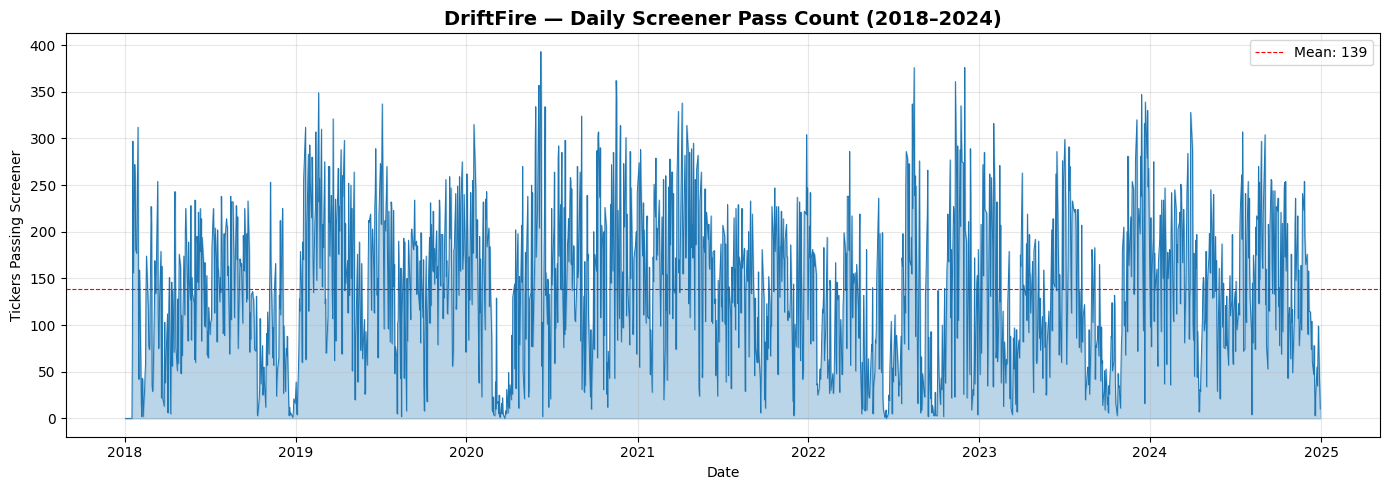


Saved → /Users/aaravaguru/Library/CloudStorage/OneDrive-IndianaUniversity/Quant Project 1 - DriftFIre/reports/figures/screener_daily_count.png


In [9]:
# ============================================================
# CELL 6 — Screener Coverage Visualization
# ============================================================
# WHAT THIS DOES:
#   Plots the daily screener pass count over time. This is
#   your first real "chart" for the project — it visually
#   validates that the screener behaves as expected:
#     - High counts during bull markets (2019, 2021)
#     - Near-zero during crashes (Mar 2020, late 2022)
#
# WHAT YOU SHOULD SEE:
#   A time series plot saved to reports/figures/. The shape
#   should mirror the S&P 500 — when markets trend up, more
#   stocks pass the "above EMA" filters.
# ============================================================
 
stocks = df[~df["is_etf"]].copy()
 
daily_count = (
    stocks[stocks["screener_pass"]]
    .groupby("date")["ticker"]
    .nunique()
    .rename("tickers_passing")
    .reindex(df["date"].drop_duplicates().sort_values(), fill_value=0)
)
 
fig, ax = plt.subplots(figsize=(14, 5))
 
ax.fill_between(daily_count.index, daily_count.values,
                alpha=0.3, color="#1f77b4")
ax.plot(daily_count.index, daily_count.values,
        linewidth=0.7, color="#1f77b4")
 
ax.set_title("DriftFire — Daily Screener Pass Count (2018–2024)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Tickers Passing Screener")
ax.axhline(y=daily_count.mean(), color="red", linestyle="--",
           linewidth=0.8, label=f"Mean: {daily_count.mean():.0f}")
ax.legend()
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(FIG_DIR / "screener_daily_count.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"\nSaved → {FIG_DIR / 'screener_daily_count.png'}")

In [10]:
# ============================================================
# CELL 7 — QA Summary & Sign-Off
# ============================================================
# WHAT THIS DOES:
#   Prints a final QA checklist. If everything above passed,
#   the data is validated and ready for feature engineering.
#
# WHAT YOU SHOULD SEE:
#   All green checkmarks. If any are red, scroll up to the
#   relevant cell and investigate before moving on.
# ============================================================
 
print("=" * 55)
print("  02_cleaning_qa.ipynb — QA SUMMARY")
print("=" * 55)
 
# re-run quick checks
stocks = df[~df["is_etf"]]
critical_ok   = df[["date","ticker","close","volume"]].isnull().sum().sum() == 0
no_dupes      = df.duplicated(subset=["ticker","date"]).sum() == 0
no_zero_vol   = (df["volume"] == 0).sum() == 0
no_neg_price  = (df["close"] < 0).sum() == 0
screener_ok   = stocks["screener_pass"].sum() > 0  # at least some pass
rows_ok       = len(df) > 500_000
 
checks = [
    ("No NaNs in critical columns", critical_ok),
    ("No duplicate (ticker, date) pairs", no_dupes),
    ("No zero-volume rows", no_zero_vol),
    ("No negative prices", no_neg_price),
    ("Screener producing results", screener_ok),
    ("Dataset size reasonable (>500K rows)", rows_ok),
]
 
all_pass = True
for label, passed in checks:
    icon = "✅" if passed else "❌"
    if not passed:
        all_pass = False
    print(f"  {icon}  {label}")
 
print(f"\n{'='*55}")
if all_pass:
    print("  ✅ ALL CHECKS PASSED — data is clean.")
    print("  Next step → 03_feature_engineering.ipynb")
else:
    print("  ❌ SOME CHECKS FAILED — scroll up to investigate.")
print(f"{'='*55}")
 

  02_cleaning_qa.ipynb — QA SUMMARY
  ✅  No NaNs in critical columns
  ✅  No duplicate (ticker, date) pairs
  ✅  No zero-volume rows
  ✅  No negative prices
  ✅  Screener producing results
  ✅  Dataset size reasonable (>500K rows)

  ✅ ALL CHECKS PASSED — data is clean.
  Next step → 03_feature_engineering.ipynb
